In [3]:
# I used the kaggle's code to get the data but there was an issue downloading it this way, so in the next chunk
#I'll download the kagglehub package 

import kagglehub

# Download latest version
path = kagglehub.dataset_download("alzyood95/jordan-cars-market-2026")

print("Path to dataset files:", path)


100%|██████████████████████████████████████| 42.4k/42.4k [00:00<00:00, 25.1MB/s]

Extracting files...
Path to dataset files: /Users/luiza/.cache/kagglehub/datasets/alzyood95/jordan-cars-market-2026/versions/1


In [2]:
!pip install kagglehub

  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/a4/8e/4077b08b95a1f8302c694a8b399bd413815fbe89045c41e6e08cd7d9439a/kagglehub-0.3.13-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 1.4 MB/s eta 0:00:00a 0:00:01


In [4]:
# now i want to see which files were downloaded 
import os

print("Path to dataset files:", path)
print("Files inside the folder:")
print(os.listdir(path))

Path to dataset files: /Users/luiza/.cache/kagglehub/datasets/alzyood95/jordan-cars-market-2026/versions/1
Files inside the folder:
['cars.csv']


In [36]:
# reading the data

import pandas as pd

file_path = os.path.join(path, "cars.csv")  # replace with actual file name
df = pd.read_csv(file_path)

df.head()

,ID,Model,Year,Condition,Fuel Type,Mileage,Seller Type,Location,Price,Insurance,Transmission,Color
0,1,Toyota Camry GLE,2023,used,Hybrid,"70,000 - 79,999 km",subjective,"Ramtha, Ramtha","22,500 JOD",No insurance,Automatic,white
1,2,BMW X5 Series xDrive40i,2020,used,gasoline,"100,000 - 109,999 km",undefined,"Amman, the chair","64,399 JOD",No insurance,Automatic,beige
2,3,Mercedes-Benz SS-Class 320,2020,New (Zero),gasoline,"40,000 - 49,999 km",an agency,"Amman, Abdoun","9,500 JOD",No insurance,Automatic,brown
3,4,Toyota Land Cruiser VXR,2014,used,gasoline,"100,000 - 109,999 km",undefined,"Amman, Al-Jubaiha","53,000 JOD",No insurance,Automatic,white
4,5,Jeep Gladiator Sport,2021,New (Zero),gasoline,"30,000 - 39,999 km",an agency,"Amman, Khalda","37,000 JOD",No insurance,Automatic,beige


In [37]:
# I can see that we've got 12 columns with different characteristics of cars, and now I will check the data types
# of each of the columns, to see if there is something to be changed 

df.dtypes


ID               int64
Model           object
Year             int64
Condition       object
Fuel Type       object
Mileage         object
Seller Type     object
Location        object
Price           object
Insurance       object
Transmission    object
Color           object
dtype: object

In [38]:
# from the obtained results we can see that there are some columns that don't match their categories, which are Price
# which should be float but is an object

# I'll replace the name Price to Price in JOD so that we don't lose the info about currency and don't misuse it as 
# dollar 

df["Price in JOD"] = (
    df["Price"]
    .str.replace(" JOD", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)


In [13]:

# the next issue is with Mileage. One idea I had was to take the average value of the range, and use this as numeric
# but in this case, we would lose data, so I think it would be the best to have separate columns for Mileage as 
# Mileage from and Mileage to, keeping two of the values as numeric types 

# I will firstly remove text and comas

df["Mileage"] = (
    df["Mileage"]
    .str.replace(" km", "", regex=False)
    .str.replace(",", "", regex=False)
)

#then, split into two columns

df[["Mileage From (km)", "Mileage To (km)"]] = (
    df["Mileage"]
    .str.split("-", expand=True)
    .astype(int)
)

# and drop the original Mileage column 
df.drop(columns=["Mileage"], inplace=True)

ValueError: invalid literal for int() with base 10: '200km'

In [39]:
#I got an error trying to run this code, saying ValueError: invalid literal for int() with base 10: '200km', so 
# I can see that the pattern is not the same for all the Mileage column ranges, meaning that some have a space after the 
# last number and some dont
df["Mileage"].unique()[:20]


# I can see that this column has three different types which are Normal range, eg "70000 - 79999", 
#single value,  "0" and open-ended value, "+200000"


array(['70,000 - 79,999 km', '100,000 - 109,999 km', '40,000 - 49,999 km',
       '30,000 - 39,999 km', '80,000 - 89,999 km', '50,000 - 59,999 km',
       '10,000 - 19,999 km', '20,000 - 29,999 km', '1,000 - 9,999 km',
       '160,000 - 169,999 km', '170,000 - 179,999 km',
       '90,000 - 99,999 km', '190,000 - 199,999 km',
       '140,000 - 149,999 km', '130,000 - 139,999 km', '0 km',
       '+200,000 km', '150,000 - 159,999 km', '110,000 - 119,999 km',
       '180,000 - 189,999 km'], dtype=object)

In [40]:
# firstly, I will remove everything that is not a range 
df["Mileage_clean"] = df["Mileage"].str.replace(r"[^\d\-]", "", regex=True)
df["Mileage_clean"].unique()


array(['70000-79999', '100000-109999', '40000-49999', '30000-39999',
       '80000-89999', '50000-59999', '10000-19999', '20000-29999',
       '1000-9999', '160000-169999', '170000-179999', '90000-99999',
       '190000-199999', '140000-149999', '130000-139999', '0', '200000',
       '150000-159999', '110000-119999', '180000-189999', '60000-69999',
       '120000-129999', '1200', '200', '80', '', '210', '1-999', '95'],
      dtype=object)

In [41]:
df[df["Mileage_clean"] == ""]

,ID,Model,Year,Condition,Fuel Type,Mileage,Seller Type,Location,Price,Insurance,Transmission,Color,Price in JOD,Mileage_clean
378,379,Jetour T2,2025,New (Zero),Hybrid,km,undefined,"Amman, Al Rabieh","37,000 JOD",No insurance,Automatic,black,37000.0,
1772,1773,Kia EV6 GT-Line AWD,2024,New (Zero),electricity,km,undefined,"Amman, Al Rabieh","27,900 JOD",No insurance,Automatic,beige,27900.0,
1934,1935,Toyota Corolla Cross GLI,2025,New (Zero),Hybrid,km,undefined,"Amman, Wadi Saqra","26,750 JOD",No insurance,Automatic,white,26750.0,


In [42]:
df.loc[df["Mileage_clean"] == "", "Mileage"]

378     km
1772    km
1934    km
Name: Mileage, dtype: object

In [50]:
# now, I can see what is the reason that this happens, we've got thee km rows that represent nothing, so we should decide
# on what to do with these. I looked at the years of the cars, and those are etiher 2025 or 2024, so replacing their
# Mileages with 0 will not harm our analysis 

df.loc[df["Year"] == 2024, "Mileage"]

48                    0 km
57                    0 km
59                    0 km
78                    0 km
116                   0 km
               ...        
2017      1,000 - 9,999 km
2051            1 - 999 km
2073    40,000 - 49,999 km
2087                  0 km
2094                  0 km
Name: Mileage, Length: 83, dtype: object

In [51]:
df.loc[df["Year"] == 2025, "Mileage"] # so, mostly those are either 0 or close to 0 

49      0 km
62      0 km
63      0 km
65      0 km
79      0 km
        ... 
1993    0 km
2030    0 km
2034    0 km
2076    0 km
2081    0 km
Name: Mileage, Length: 95, dtype: object

In [56]:
# replacing the empty strings with 0 

df.loc[df["Mileage_clean"] == "", "Mileage_clean"] = "0"

# and then splitting ranges 
split_vals = df["Mileage_clean"].str.split("-", expand=True)
df["Mileage From (km)"] = pd.to_numeric(split_vals[0], errors="coerce")
df["Mileage To (km)"] = pd.to_numeric(split_vals[1], errors="coerce")
df["Mileage To (km)"] = df["Mileage To (km)"].fillna(df["Mileage From (km)"])

df.dtypes

ID                     int64
Model                 object
Year                   int64
Condition             object
Fuel Type             object
Mileage               object
Seller Type           object
Location              object
Price                 object
Insurance             object
Transmission          object
Color                 object
Price in JOD         float64
Mileage_clean         object
Mileage From (km)      int64
Mileage To (km)      float64
dtype: object

In [57]:
# I can see that one of Mileages is float and another one is int, so I'll keep them both in the same way 
df["Mileage From (km)"] = df["Mileage From (km)"].astype("Int64")
df["Mileage To (km)"] = df["Mileage To (km)"].astype("Int64")

In [58]:
# now checking the types one more time 
df.dtypes

ID                     int64
Model                 object
Year                   int64
Condition             object
Fuel Type             object
Mileage               object
Seller Type           object
Location              object
Price                 object
Insurance             object
Transmission          object
Color                 object
Price in JOD         float64
Mileage_clean         object
Mileage From (km)      Int64
Mileage To (km)        Int64
dtype: object

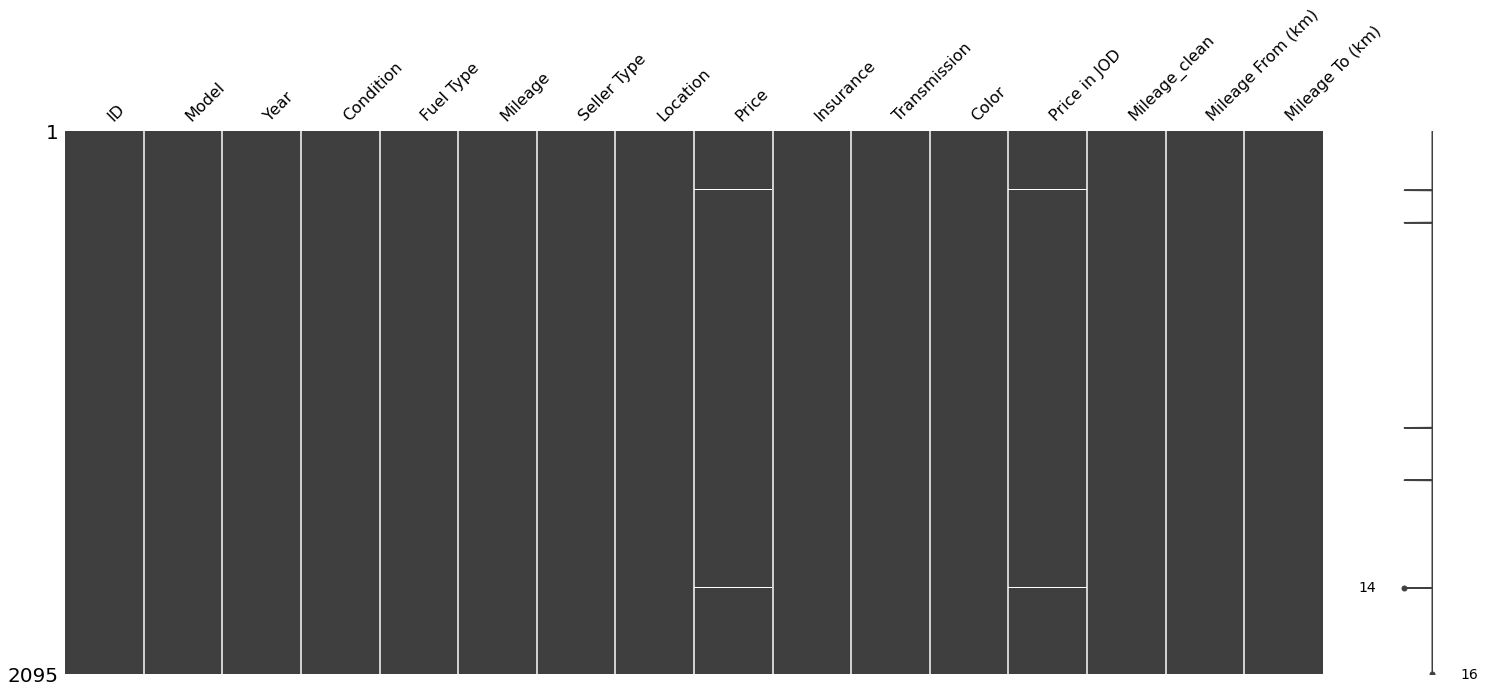

In [59]:
# after changing the types, I can get to EDA finally, I will start from exploring missing values using the library
# missingno as we discussed during the previous lecture 

import missingno as msno
import matplotlib.pyplot as plt

# plotting the basic missing data matrix
msno.matrix(df)
plt.show()


In [65]:
# from the visualization above, I understood that I forgot to drop the unnecessary columns Price, Mileage and
#Mileage_clean

# Drop unnecessary columns

df.drop(columns=["Mileage", "Mileage_clean", "Price"], inplace=True)
df.head(5)

,ID,Model,Year,Condition,Fuel Type,Seller Type,Location,Insurance,Transmission,Color,Price in JOD,Mileage From (km),Mileage To (km)
0,1,Toyota Camry GLE,2023,used,Hybrid,subjective,"Ramtha, Ramtha",No insurance,Automatic,white,22500.0,70000,79999
1,2,BMW X5 Series xDrive40i,2020,used,gasoline,undefined,"Amman, the chair",No insurance,Automatic,beige,64399.0,100000,109999
2,3,Mercedes-Benz SS-Class 320,2020,New (Zero),gasoline,an agency,"Amman, Abdoun",No insurance,Automatic,brown,9500.0,40000,49999
3,4,Toyota Land Cruiser VXR,2014,used,gasoline,undefined,"Amman, Al-Jubaiha",No insurance,Automatic,white,53000.0,100000,109999
4,5,Jeep Gladiator Sport,2021,New (Zero),gasoline,an agency,"Amman, Khalda",No insurance,Automatic,beige,37000.0,30000,39999


In [68]:
# from the previous visualization I noticed that the only variable that has a missing value is Price in JOD, 
# so I think that there is no more need to continue analyzing null values correlations or distributions, and
# we don't have the Mileage Null values because I changed them by 0. However, not to bring back the Mileage
# column to see whether there is a correlation between Mileage and Price Null values, I can simply see the 
# columns of the Null and values and see whether they correspond or not 

df[df["Price in JOD"].isna()]

# in my previous part of the code I can see that in the Mileage I had null values in the rows 378, 1772, 1934
# and none corresponds to the null values of Price in JOD, so there is no correlation between these two

,ID,Model,Year,Condition,Fuel Type,Seller Type,Location,Insurance,Transmission,Color,Price in JOD,Mileage From (km),Mileage To (km)
229,230,Mercedes-Benz CC-Class 200,2019,used,Hybrid,undefined,"Amman, Dabouq",No insurance,Automatic,black,NaN,150000,159999
354,355,Dongfeng Sky EV01,2025,New (Zero),electricity,undefined,"Amman, Al Rabieh",No insurance,Automatic,beige,NaN,0,0
1144,1145,Mercedes-Benz CC-Class 200,2019,used,Hybrid,undefined,"Amman, Dabouq",No insurance,Automatic,black,NaN,150000,159999
1346,1347,Dongfeng Sky EV01,2025,New (Zero),electricity,undefined,"Amman, Al Rabieh",No insurance,Automatic,beige,NaN,0,0
1761,1762,Volkswagen ID 4 ID.4 X,2023,used,electricity,undefined,"Amman, Dabouq",No insurance,Automatic,beige,NaN,40000,49999


In [70]:
# to handle the null values in Price in JOD, I can replace those with similar values or drop (same car of the same year
#, and the same Condition)
# I will not match with the others because these are the main representatives (and of course the mileage, but
# it is a little likely that we will get the same Mileage )

import pandas as pd

# finding all rows with missing Price
missing_price_idx = df[df["Price in JOD"].isna()].index

for idx in missing_price_idx:
    # getting the row details
    row = df.loc[idx]
    model = row["Model"]
    year = row["Year"]
    condition = row["Condition"]

    # filtering the dataframe for the same Model, Year, and Condition
    similar_cars = df[
        (df["Model"] == model) &
        (df["Year"] == year) &
        (df["Condition"] == condition) &
        (df["Price in JOD"].notna())  # only consider rows with price
    ]

    if not similar_cars.empty:
        # Using the median price of similar cars
        median_price = similar_cars["Price in JOD"].median()
        df.loc[idx, "Price in JOD"] = median_price
    else:
        # Fallback: using overall median
        df.loc[idx, "Price in JOD"] = df["Price in JOD"].median()

# checking that there are no more missing values
print(df["Price in JOD"].isna().sum())

# now, there are no more missing values 

0


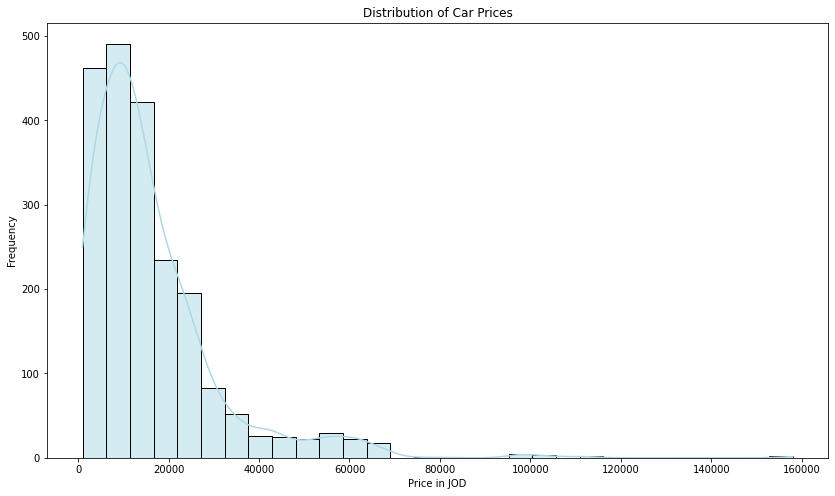

In [120]:
# as a continuation, I will start plotting different variables with each other to understand how they behave and 
# what can be inferred 

#firstly, I will plot Price with how many cars have specific prices. Since both of the variables are numeric, 
# I think plotting a histogram is a good idea 

import seaborn as sns
plt.figure(figsize=(14, 8))  

sns.histplot(df["Price in JOD"], bins=30, kde=True, color="lightblue")

plt.title("Distribution of Car Prices")
plt.xlabel("Price in JOD")
plt.ylabel("Frequency")
plt.show()
# from this visualization, we can see that the data contains mostly low-value vehicles, since the prices are mostly
# concentrated from 0-25000 JOD. 

In [78]:
#Since the price cannot be 0, I would like to see the minimal value of the cars, since the visualization contains
# a wide range, so it is around 0

print(df["Price in JOD"].min())
print(df["Price in JOD"].max())

# the prices range from 1000-158000 JOD (1410-222851.89 USD)

1000.0
158000.0


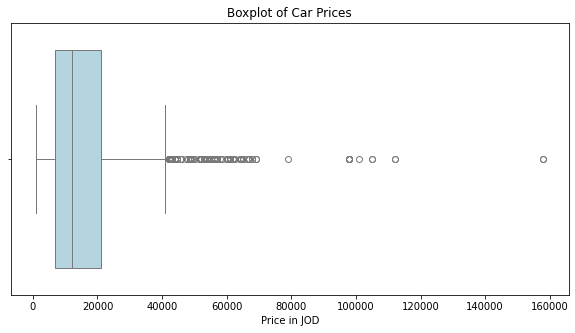

In [116]:
# since from the first visualization I made a suspicion about outliers (actually, it's obvious), I will continue 
#analyzing outliers

plt.figure(figsize=(10, 5))  

sns.boxplot(x=df["Price in JOD"], color="lightblue")

plt.title("Boxplot of Car Prices")
plt.xlabel("Price in JOD")
plt.show()

# from here, we can see that 1580.000 JOD priced car is an extreme luxury, since it's very far from the previous 
#outlier, and I can confirm my statement that the median value of the cars is in the lower range around 10.000-JOD

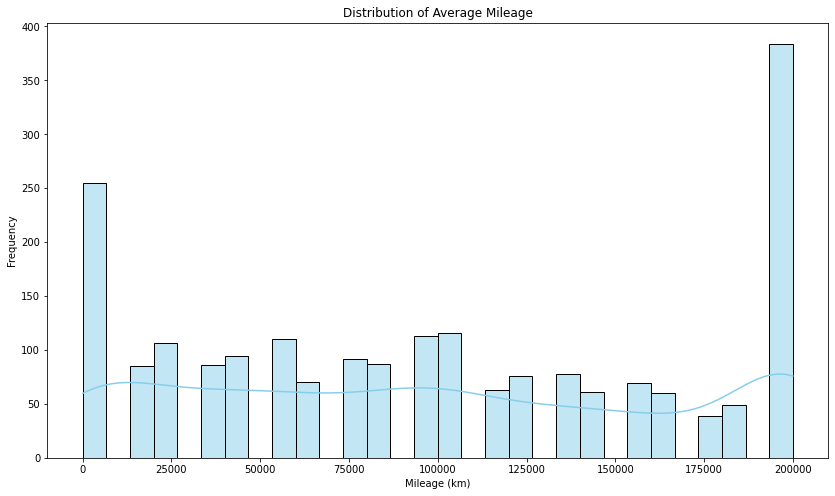

In [110]:
#continuing the numeric variables' part, I will continue to Mileage from and Mileage to exploration 

# I will add an average mileage column to make it easier the visualization 

df["Mileage Avg (km)"] = (
    df["Mileage From (km)"] + df["Mileage To (km)"]
) / 2

plt.figure(figsize=(14, 8))  

sns.histplot(df["Mileage Avg (km)"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of Average Mileage")
plt.xlabel("Mileage (km)")
plt.ylabel("Frequency")
plt.show()

# from this visualization we can see that mostly, the cars have a Mileage more than 200.000. This is
# easy to understand, since this category (200.000+) has more values in it than all the previous numbers. Also, 
# this explains the fact that the cars are mostly low-cost in this data, since the more the Mileage, the less the 
# price 

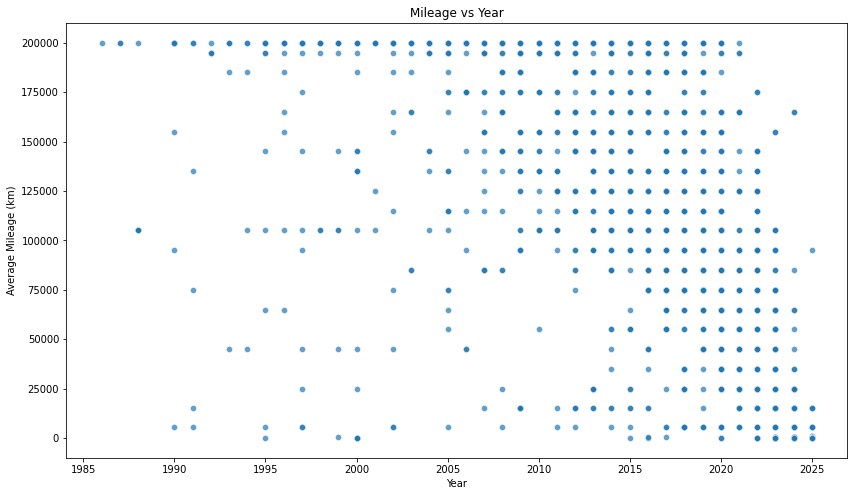

In [109]:
# I will also check Mileage and Year correlations, if our data is fine, the older the car, the more the Mileage 
plt.figure(figsize=(14, 8)) 

sns.scatterplot(
    x="Year",
    y="Mileage Avg (km)",
    data=df,
    alpha=0.7  
)

plt.title("Mileage vs Year")
plt.xlabel("Year")
plt.ylabel("Average Mileage (km)")
plt.show()
# here we can see a clear outlier of the Year variable which is a car older than 1970, with 0 Mileage. Of course, 
# this is very interesting (possibly, either a mistake or a vintage car that was bought and never utilized)
# for the other values, we can see that after 2020, there are a few cars that have a Mileage higher than 200.000
# which is okay 

In [86]:
# I am interested to see which car older than 1970 has a mileage of around 0. 
oldest_year = df["Year"].min()
oldest_cars = df[df["Year"] == oldest_year]
oldest_cars

# I looked online and saw that there is no car called Paw 212 and its unusual mileage of 0 also makes it look 
# suspicious, (also a car of the year 1965 with automatic transmission is not likely
# to be 14900 JOD) so I will drop these duplicated rows 

,ID,Model,Year,Condition,Fuel Type,Seller Type,Location,Insurance,Transmission,Color,Price in JOD,Mileage From (km),Mileage To (km),Mileage Avg (km)
312,313,Paw 212,1965,New (Zero),gasoline,undefined,"Amman, Tabarbour",No insurance,Automatic,My cement,14900.0,0,0,0.0
1292,1293,Paw 212,1965,New (Zero),gasoline,undefined,"Amman, Tabarbour",No insurance,Automatic,My cement,14900.0,0,0,0.0


In [87]:
# dropping these two rows 
df = df[df["Year"] != df["Year"].min()]

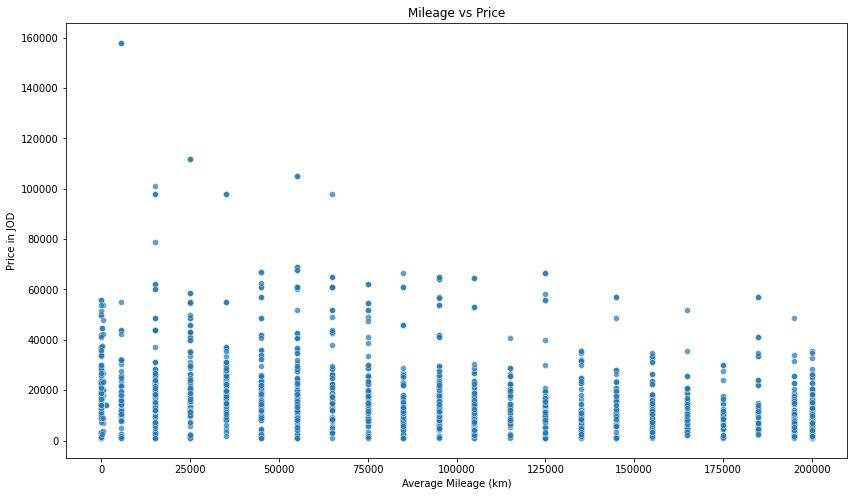

In [106]:
# also, since I have some guesses about Price-Mileage Correlations, I will plot them next to each other too 
plt.figure(figsize=(14, 8))  

sns.scatterplot(
    x="Mileage Avg (km)",
    y="Price in JOD",
    data=df,
    alpha=0.7 
)

plt.title("Mileage vs Price")
plt.xlabel("Average Mileage (km)")
plt.ylabel("Price in JOD")
plt.show()

# in this visualization we can see that the biggest prices, indeed, occur wherever the mileages are less than 60.000
#km, which is intuitive. 

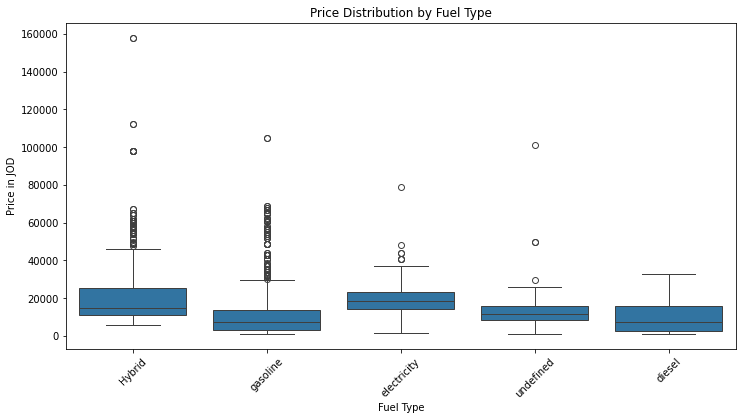

In [105]:
# now, coming to the categorical variables, I will make some plots, and so sum up the EDA part 
plt.figure(figsize=(12, 6)) 

sns.boxplot(
    x="Fuel Type",
    y="Price in JOD",
    data=df
)

plt.xticks(rotation=45)  
plt.title("Price Distribution by Fuel Type")
plt.show()

# From the boxplots below, we can see that the prices are the highest when the cars are either hybrid or electrical.
# And mostly, the upper outliers occur in case of hybrid cars or gasoline ones. Actually, this is very intuitive 
# since hybrid cars give their drivers the opportunity to utilize the vehice with both options, increasing the price
# of the car, and about gasoline, most probably there are mostly gasoline cars in the dataset since those started 
# being produced far earlier than electrical cars, making their mean be lower, since those were produced both 
# earlier and until now. And electrical cars have a very low maintanance cost (and are newer), so are higher priced.

# actually, one of my favorite cars corresponds to all features of this hybrid outlier, so I'll look for it to
# see if it is BMW XM 

In [92]:
 df.loc[df["Price in JOD"].idxmax()]

# I was right to think that this was the BMW XM car, because it is one of the highest priced hybrid cars currently in
# the market. This step just for my curiousity 

ID                                494
Model                BMW XM Series XM
Year                             2024
Condition                        used
Fuel Type                      Hybrid
Seller Type            Gallery/Agency
Location             Amman, Al Rabieh
Insurance                No insurance
Transmission                Automatic
Color                           ashen
Price in JOD                 158000.0
Mileage From (km)                1000
Mileage To (km)                  9999
Mileage Avg (km)               5499.5
Name: 493, dtype: object

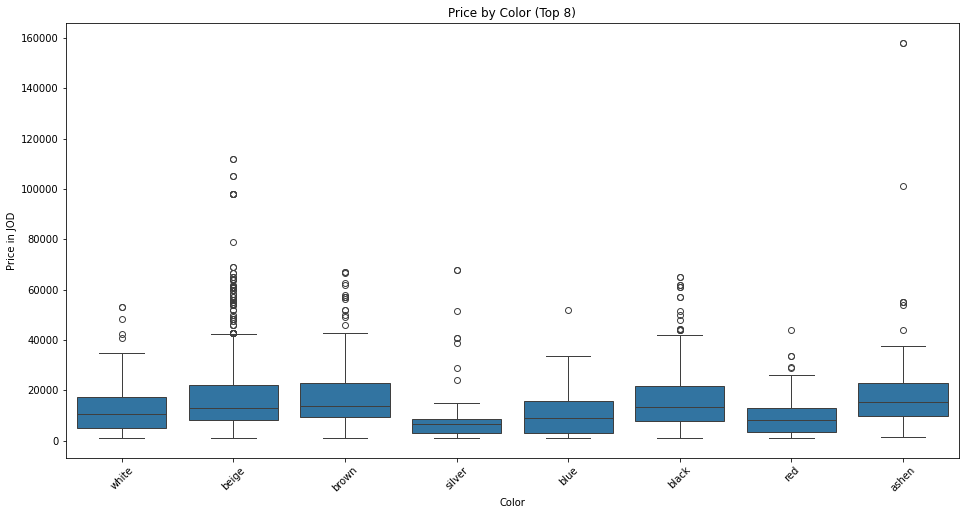

In [104]:
# next I will test Colors and Prices to see whether those are correlated 
top_colors = df["Color"].value_counts().head(8).index
plt.figure(figsize=(16, 8)) 

sns.boxplot(
    x="Color",
    y="Price in JOD",
    data=df[df["Color"].isin(top_colors)]
)

plt.xticks(rotation=45)  
plt.title("Price by Color (Top 8)")
plt.show()

# interestingly, the prices are correlated with colors, and most expensive ones are beige, brown and black. The lowest
# priced ones are mostly silver 

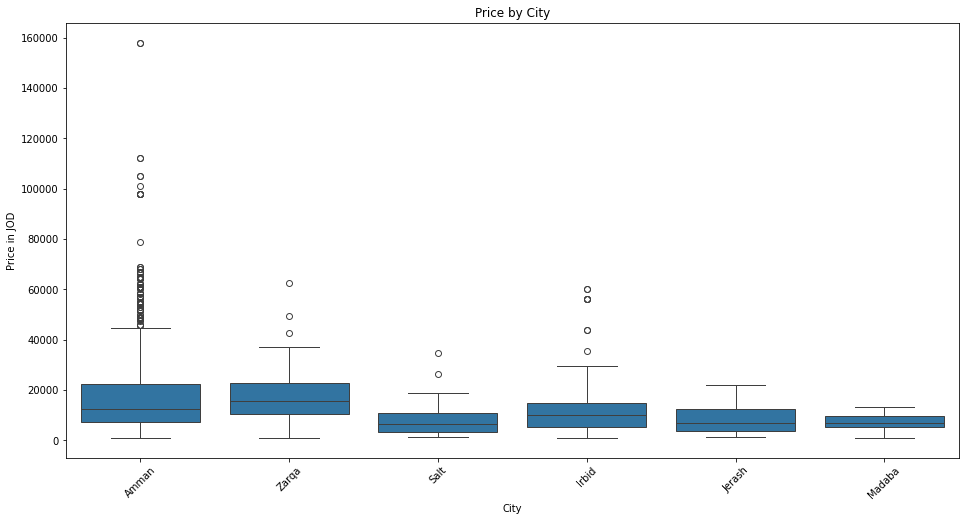

In [103]:
# for next visualization, I would like to extract City from the column Location 
df = df.copy()
df["City"] = df["Location"].str.split(",").str[0]

top_cities = df["City"].value_counts().head(6).index
plt.figure(figsize=(16, 8)) 

sns.boxplot(
    x="City",
    y="Price in JOD",
    data=df[df["City"].isin(top_cities)]
)

plt.xticks(rotation=45) 
plt.title("Price by City")
plt.show()

# the prices indicate that mostly the cars have higher prices in Amman and Zarqa. I know that Amman is the capital
# of Jordan, which makes sense. I looked up online and saw that Zarqa is the second city of Jordan, which makes this 
# result very likely. 

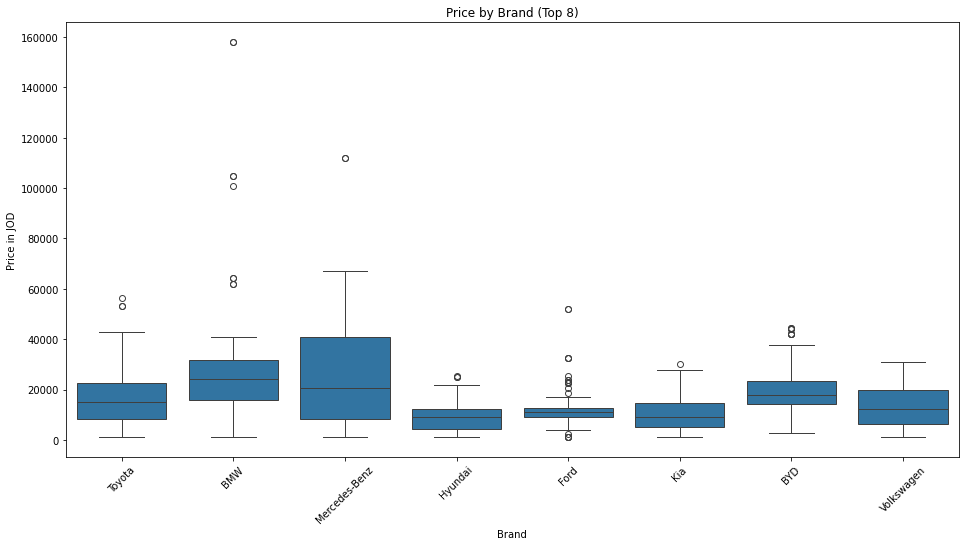

In [102]:
# Lastly, I would like to see the correlation of the brands of the cars and their prices 

df["Brand"] = df["Model"].str.split().str[0]

top_brands = df["Brand"].value_counts().head(8).index

# Make the figure bigger
plt.figure(figsize=(16, 8))  # Width=16, Height=8

sns.boxplot(
    x="Brand",
    y="Price in JOD",
    data=df[df["Brand"].isin(top_brands)]
)

plt.xticks(rotation=45)  # Rotate x labels for readability
plt.title("Price by Brand (Top 8)")
plt.show()

# here we can observe a very interesting picture. Of course, BMW and Mercedes-Benz have higher prices than the others.
# but what is interesting to me is the spread of Mercedes-Benz distribution. In my opinion, this can be explained
# by the fact that car enthusiasts prefer BMW engines to be worked on and keep these cars in good condition 
# which is why it is more centered. However, the older cars of Mercedes-Benz (despite W140), are losing their value

# To make this visualization make more sense, I will add Years 

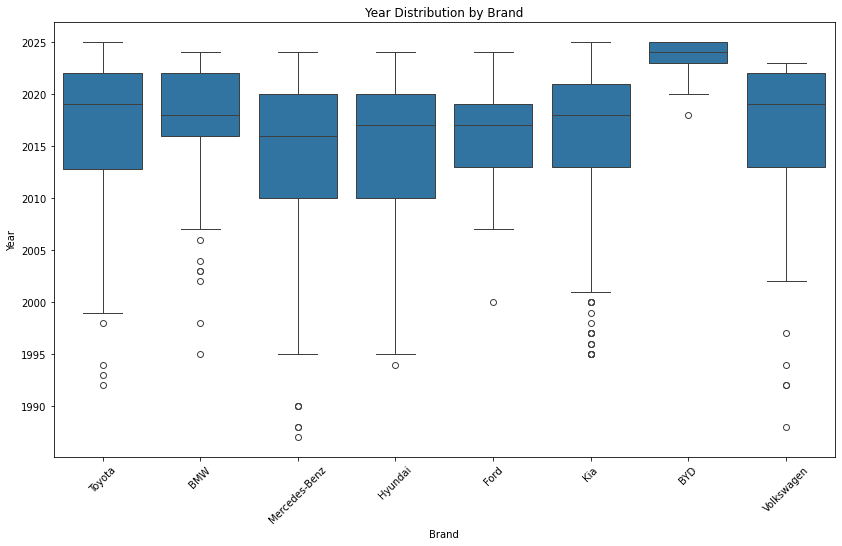

In [101]:

plt.figure(figsize=(14, 8))  # Width=14, Height=8
sns.boxplot(
    x="Brand",
    y="Year",
    data=df[df["Brand"].isin(top_brands)]
)
plt.xticks(rotation=45)  # Rotate x labels for readability
plt.title("Year Distribution by Brand")
plt.show()

# So now we can draw some new insights. Based on these two plots we can now see why the BYD has higher prices than 
# Volkswagen, KIA and some other brands. It is because the BYD is a new company in the automotive world and their
# prices are not spread and keep the company average price high. Also we can assume that Toyota, Mercedes-Benz and 
# Volkswagen are the most reliable in this list as they are the top 3 companies with cars that are outliers and 
# were made before 1995. And Hyundai can also be mentioned as its interquartile range is very big and it shows
# that a lot of Hyundais are old cars that can still be used. 